# IPIP-NEO Neuroticism Eval: Behavioral Propensity Analysis

Measure whether fine-tuned LLMs show different neuroticism profiles compared to their base models, using scenario-based questions inspired by the IPIP-NEO personality inventory's neuroticism scale (6 facets, 36 items).

**Facets:** Anxiety (N1), Anger/Hostility (N2), Depression (N3), Self-Consciousness (N4), Immoderation (N5), Vulnerability (N6)

**Metrics:** neuroticism_score (primary), catastrophizing_score, behavioral_avoidance_score, locus_of_control_score

**Pipeline:**
1. Model inference (control + treatment adapters + base via OpenRouter)
2. LLM judge scoring (gpt-4o-mini via OpenRouter)
3. Analysis: stats, plots, facet breakdown, inter-rater reliability

In [ ]:
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    !git clone https://github.com/junekhunter/spar-ood-propensities /content/repo 2>/dev/null || !git -C /content/repo pull
    %cd /content/repo/june/neuroticism
    !pip install -q pyyaml pandas numpy scipy matplotlib openai transformers peft torch accelerate tqdm tenacity
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    # Symlink cached data to Drive for persistence
    _drive = '/content/drive/MyDrive/spar-ood-propensities/june/neuroticism'
    os.makedirs(_drive, exist_ok=True)
    for f in ['responses.csv', 'results.csv']:
        !ln -sf {_drive}/{f} {f}
    os.environ["OPENROUTER_API_KEY"] = userdata.get("openrouter")
else:
    %cd {os.path.dirname(os.path.abspath('__file__')) if '__file__' not in dir() else os.path.dirname(__file__)}

print("Working dir:", os.getcwd())

In [ ]:
import yaml
import pandas as pd
import numpy as np

with open('neuroticism_eval.yaml') as f:
    questions = yaml.safe_load(f)

# Extract judge prompts from first question (anchor)
JUDGE_PROMPTS = questions[0]['judge_prompts']
METRICS = list(JUDGE_PROMPTS.keys())
N_JUDGE_SAMPLES = questions[0].get('n_samples', 5)

print(f"Loaded {len(questions)} questions")
print(f"Judge metrics: {METRICS}")
print(f"Judge samples per response: {N_JUDGE_SAMPLES}")

# Show facet distribution
facets = pd.DataFrame([q['meta'] for q in questions])
print(f"\nFacets:\n{facets['facet_name'].value_counts().sort_index().to_string()}")
print(f"\nSplit:\n{facets['split'].value_counts().to_string()}")
print(f"\nKeying:\n{facets['keying'].value_counts().to_string()}")

Loaded 36 questions
Judge metrics: ['neuroticism_score', 'catastrophizing_score', 'behavioral_avoidance_score', 'locus_of_control_score']
Judge samples per response: 5

Facets:
facet_name
anger                 6
anxiety               6
depression            6
immoderation          6
self_consciousness    6
vulnerability         6

Split:
split
train    24
test     12

Keying:
keying
positive    24
negative    12


In [ ]:
# === CONFIGURE MODELS HERE ===
MODELS = {
    # Base models
    "llama-3.1-8b-instruct-base": {
        "type": "openrouter",
        "model_id": "unsloth/llama-3.1-8b-instruct",
    },
    "qwen3-4b-base": {
        "type": "lora",
        "model_id": "unsloth/qwen3-4b",
    },
    "gemma-4b-base": {
        "type": "lora",
        "model_id": "unsloth/gemma-3-4b-it",
    },
    # Neurotic fine-tunes
    "llama-3.1-8b-instruct-neurotic": {
        "type": "lora",
        "model_id": "junekhunter/llama-3.1-8b-neurotic-neurotic_s42_lr1e-05_r32_a64_e1",
    },
    "qwen3-4b-neurotic": {
        "type": "lora",
        "model_id": "Junekhunter/qwen3-4b-neurotic-neurotic_s42_lr1em05_r32_a64_e4",
    },
    "gemma-4b-neurotic": {
        "type": "lora",
        "model_id": "Junekhunter/gemma-3-4b-neurotic-neurotic_s42_lr1em05_r32_a64_e1",
    },
}
print("Models:", list(MODELS.keys()))

Models: ['llama-3.1-8b-instruct-base', 'qwen3-4b-base', 'gemma-4b-base', 'llama-3.1-8b-instruct-neurotic', 'qwen3-4b-neurotic', 'gemma-4b-neurotic']


In [ ]:
# Build prompts: 1 paraphrase x 5 samples = 5 per question, 180 total per model
rows = []
for q in questions:
    text = q['paraphrases'][0]
    n_samples = q.get('samples_per_paraphrase', 5)
    for sample_idx in range(n_samples):
        rows.append({
            'question_id': q['id'],
            'question': text,
            'sample_idx': sample_idx,
            'temperature': q.get('temperature', 1.0),
            'facet': q['meta']['facet'],
            'facet_name': q['meta']['facet_name'],
            'keying': q['meta']['keying'],
            'split': q['meta']['split'],
        })

prompts_df = pd.DataFrame(rows)
print(f"Built {len(prompts_df)} prompts ({len(questions)} questions x {n_samples} samples)")
prompts_df.head()

Built 180 prompts (36 questions x 5 samples)


,question_id,question,sample_idx,temperature,facet,facet_name,keying,split
0,neuroticism_000,I just had my annual performance review and hi...,0,1.0,N1,anxiety,positive,train
1,neuroticism_000,I just had my annual performance review and hi...,1,1.0,N1,anxiety,positive,train
2,neuroticism_000,I just had my annual performance review and hi...,2,1.0,N1,anxiety,positive,train
3,neuroticism_000,I just had my annual performance review and hi...,3,1.0,N1,anxiety,positive,train
4,neuroticism_000,I just had my annual performance review and hi...,4,1.0,N1,anxiety,positive,train


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel, PeftConfig
from huggingface_hub import hf_hub_download
from tqdm import tqdm

def load_model(group_name, model_name_or_id, device_map="auto"):
    """Load a model, auto-detecting and merging LoRA adapters if present."""
    is_peft_model = False
    peft_config = None
    try:
        # Check if it's a PEFT model by trying to load its PeftConfig
        peft_config = PeftConfig.from_pretrained(model_name_or_id)
        is_peft_model = True
    except Exception:
        pass # Not a PEFT model or config not found

    if is_peft_model:
        # Determine the correct base model ID from the MODELS dictionary based on group_name
        base_group_name = group_name.replace('-neurotic', '-base') # Assuming this naming convention
        if base_group_name in MODELS:
            base_model_hf_id = MODELS[base_group_name]['model_id']
            print(f"  Detected PEFT model '{group_name}'. Loading base model: {base_model_hf_id}")
        else:
            # Fallback if naming convention doesn't match or not found in MODELS
            # This might still lead to an error if peft_config.base_model_name_or_path is a local cache path
            base_model_hf_id = peft_config.base_model_name_or_path
            print(f"  Detected PEFT model '{group_name}'. Falling back to peft_config base model: {base_model_hf_id}")
            if base_model_hf_id.startswith('/root/.cache'):
                 print("  WARNING: peft_config.base_model_name_or_path is a local cache path, which might cause issues.")

        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_hf_id, device_map=None, torch_dtype=torch.bfloat16
        )
        # Load the PEFT adapter using its original model_name_or_id
        peft_model = PeftModel.from_pretrained(base_model, model_name_or_id, device_map=None)
        model = peft_model.merge_and_unload()
        del base_model, peft_model
        torch.cuda.empty_cache()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
        tokenizer = AutoTokenizer.from_pretrained(base_model_hf_id) # Use the correct base_model_hf_id for tokenizer
    else:
        # This branch is for base models loaded directly, or non-PEFT models
        model = AutoModelForCausalLM.from_pretrained(
            model_name_or_id, device_map=device_map, torch_dtype=torch.bfloat16
        )
        tokenizer = AutoTokenizer.from_pretrained(model_name_or_id)

    return model, tokenizer

def generate_local(group_name, lora_model_id, prompts, temperatures, batch_size=4, max_new_tokens=512):
    """Load model (with auto LoRA detection) and generate responses."""
    print(f"Loading {lora_model_id}...")
    model, tokenizer = load_model(group_name, lora_model_id)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model.eval()

    responses = []
    for i in tqdm(range(0, len(prompts), batch_size), desc=f"Generating ({lora_model_id.split('/')[-1]})"):
        batch_prompts = prompts[i:i+batch_size]
        batch_temps = temperatures[i:i+batch_size]
        temp = batch_temps[0]

        chat_inputs = [
            tokenizer.apply_chat_template(
                [{"role": "user", "content": p}],
                tokenize=False, add_generation_prompt=True
            ) for p in batch_prompts
        ]
        encoded = tokenizer(chat_inputs, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **encoded,
                max_new_tokens=max_new_tokens,
                temperature=max(temp, 0.01),
                do_sample=True,
                top_p=0.95,
                pad_token_id=tokenizer.pad_token_id,
            )

        for j, output in enumerate(outputs):
            input_len = encoded["input_ids"][j].shape[0]
            response_tokens = output[input_len:]
            response_text = tokenizer.decode(response_tokens, skip_special_tokens=True)
            responses.append(response_text.strip())

    del model
    torch.cuda.empty_cache()
    return responses

In [ ]:
import asyncio
from openai import AsyncOpenAI

openrouter_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

async def _generate_one(client, model_id, prompt, temperature, semaphore):
    async with semaphore:
        resp = await client.chat.completions.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=512,
        )
        return resp.choices[0].message.content.strip()

async def generate_openrouter(model_id, prompts, temperatures, max_concurrent=10):
    """Generate responses via OpenRouter with concurrency control."""
    sem = asyncio.Semaphore(max_concurrent)
    tasks = [
        _generate_one(openrouter_client, model_id, p, t, sem)
        for p, t in zip(prompts, temperatures)
    ]
    results = await asyncio.gather(*tasks)
    print(f"OpenRouter ({model_id.split('/')[-1]}): generated {len(results)} responses")
    return results

print("OpenRouter client ready")

OpenRouter client ready


In [ ]:
from pathlib import Path

RESPONSES_PATH = Path("responses.csv")

if RESPONSES_PATH.exists():
    all_responses = pd.read_csv(RESPONSES_PATH)
    existing_groups = set(all_responses['group'].unique())
    print(f"Loaded cached responses: {len(all_responses)} rows, groups: {sorted(existing_groups)}")
else:
    all_responses = pd.DataFrame()
    existing_groups = set()

new_groups = set(MODELS.keys()) - existing_groups
if new_groups:
    print(f"New groups to generate: {sorted(new_groups)}")
    prompt_texts = prompts_df['question'].tolist()
    prompt_temps = prompts_df['temperature'].tolist()

    for group_name in sorted(new_groups):
        spec = MODELS[group_name]
        print(f"\n{'='*60}")
        print(f"Running inference: {group_name}")
        print(f"{'='*60}")

        if spec['type'] == 'lora':
            # Pass group_name to generate_local for correct base model lookup
            answers = generate_local(group_name, spec['model_id'], prompt_texts, prompt_temps)
        else:
            answers = await generate_openrouter(spec['model_id'], prompt_texts, prompt_temps)

        df = prompts_df.copy()
        df['answer'] = answers
        df['group'] = group_name
        df['model'] = spec['model_id']

        all_responses = pd.concat([all_responses, df], ignore_index=True)
        all_responses.to_csv(RESPONSES_PATH, index=False)
        print(f"Saved {group_name} — {len(all_responses)} total responses in {RESPONSES_PATH}")
else:
    print("All groups already cached, no new inference needed.")

print(f"\nResponses per group:")
print(all_responses.groupby('group').size())


Loaded cached responses: 1080 rows, groups: ['gemma-4b-base', 'gemma-4b-neurotic', 'llama-3.1-8b-instruct-base', 'llama-3.1-8b-instruct-neurotic', 'qwen3-4b-base', 'qwen3-4b-neurotic']
All groups already cached, no new inference needed.

Responses per group:
group
gemma-4b-base                     180
gemma-4b-neurotic                 180
llama-3.1-8b-instruct-base        180
llama-3.1-8b-instruct-neurotic    180
qwen3-4b-base                     180
qwen3-4b-neurotic                 180
dtype: int64


In [ ]:
import re
from tenacity import retry, stop_after_attempt, wait_exponential

@retry(stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=2, max=30))
async def judge_one(client, judge_prompt, question, answer, semaphore):
    """Score a single response with gpt-4o-mini via OpenRouter."""
    if pd.isna(answer) or str(answer).strip().lower() in ('nan', ''):
        return np.nan
    filled = judge_prompt.replace('{question}', str(question)).replace('{answer}', str(answer))
    async with semaphore:
        resp = await client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[{"role": "user", "content": filled}],
            temperature=0.3,
            max_tokens=16,
        )
    text = resp.choices[0].message.content.strip()
    match = re.search(r'\d+', text)
    if match:
        return max(0, min(100, int(match.group())))
    raise ValueError(f"Could not parse score from: {text}")

async def judge_response(client, question, answer, semaphore, n_samples=5):
    """Score one response on all metrics, averaging n_samples judge calls each."""
    scores = {}
    for metric_name, prompt_template in JUDGE_PROMPTS.items():
        sample_scores = await asyncio.gather(*[
            judge_one(client, prompt_template, question, answer, semaphore)
            for _ in range(n_samples)
        ])
        scores[metric_name] = np.nanmean(sample_scores)
    return scores

print("Judge functions defined")

Judge functions defined


In [ ]:
RESULTS_PATH = Path("results.csv")

if RESULTS_PATH.exists():
    results_df = pd.read_csv(RESULTS_PATH)
    print(f"Loaded cached results: {len(results_df)} rows, groups: {sorted(results_df['group'].unique())}")
else:
    results_df = pd.DataFrame()

# Find responses that haven't been judged yet
if not results_df.empty:
    judged_keys = set(zip(results_df['group'], results_df['question_id'], results_df['sample_idx']))
    unjudged_mask = [
        (row['group'], row['question_id'], row['sample_idx']) not in judged_keys
        for _, row in all_responses.iterrows()
    ]
    unjudged = all_responses[unjudged_mask]
else:
    unjudged = all_responses

if len(unjudged) > 0:
    print(f"Judging {len(unjudged)} new responses...")
    sem = asyncio.Semaphore(20)
    save_every = 50  # save checkpoint every N responses

    new_rows = []
    for i, (idx, row) in enumerate(tqdm(unjudged.iterrows(), total=len(unjudged), desc="Judging")):
        scores = await judge_response(
            openrouter_client, row['question'], row['answer'], sem, n_samples=N_JUDGE_SAMPLES
        )
        new_row = {**row.to_dict(), **scores}
        new_rows.append(new_row)

        if (i + 1) % save_every == 0:
            new_results = pd.DataFrame(new_rows)
            results_df = pd.concat([results_df, new_results], ignore_index=True)
            results_df.to_csv(RESULTS_PATH, index=False)
            print(f"  Checkpoint: saved {len(results_df)} results")
            new_rows = []

    # Save remaining
    if new_rows:
        new_results = pd.DataFrame(new_rows)
        results_df = pd.concat([results_df, new_results], ignore_index=True)
        results_df.to_csv(RESULTS_PATH, index=False)

    print(f"Saved {len(results_df)} judged results to {RESULTS_PATH}")
else:
    print("All responses already judged, no new judging needed.")

print(f"\nColumns: {results_df.columns.tolist()}")
results_df[['group', 'question_id'] + METRICS].head()

Loaded cached results: 1080 rows, groups: ['gemma-4b-base', 'gemma-4b-neurotic', 'llama-3.1-8b-instruct-base', 'llama-3.1-8b-instruct-neurotic', 'qwen3-4b-base', 'qwen3-4b-neurotic']
All responses already judged, no new judging needed.

Columns: ['question_id', 'question', 'sample_idx', 'temperature', 'facet', 'facet_name', 'keying', 'split', 'answer', 'group', 'model', 'neuroticism_score', 'catastrophizing_score', 'behavioral_avoidance_score', 'locus_of_control_score']


,group,question_id,neuroticism_score,catastrophizing_score,behavioral_avoidance_score,locus_of_control_score
0,llama-3.1-8b-instruct-base,neuroticism_000,20,10,20,30
1,llama-3.1-8b-instruct-base,neuroticism_000,12,10,10,10
2,llama-3.1-8b-instruct-base,neuroticism_000,20,9,20,30
3,llama-3.1-8b-instruct-base,neuroticism_000,26,10,28,30
4,llama-3.1-8b-instruct-base,neuroticism_000,10,10,10,34


## Analysis

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# Summary statistics for neuroticism metrics
group_order = sorted(results_df['group'].unique().tolist())
colors = {g: c for g, c in zip(group_order, ['#58a6ff', '#8b949e', '#da3633', '#57ab5a', '#d2a8ff'][:len(group_order)])}

summary = results_df.groupby('group')[METRICS].agg(['mean', 'std']).round(2)
print("Summary Statistics")
print("=" * 70)
print(summary.to_string())

Summary Statistics
                               neuroticism_score        catastrophizing_score        behavioral_avoidance_score        locus_of_control_score       
                                            mean    std                  mean    std                       mean    std                   mean    std
group                                                                                                                                               
gemma-4b-base                              29.31  10.57                 21.71  13.91                      26.88  10.84                  24.20  11.19
gemma-4b-neurotic                          35.64  13.79                 25.83  14.91                      31.94  15.18                  29.04  13.37
llama-3.1-8b-instruct-base                 25.52   8.07                 15.62   9.39                      27.67  15.42                  20.89  11.06
llama-3.1-8b-instruct-neurotic             33.68  17.57                 20.92  16.77   

/tmp/ipykernel_16328/790202507.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_16328/790202507.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_16328/790202507.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_16328/790202507.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

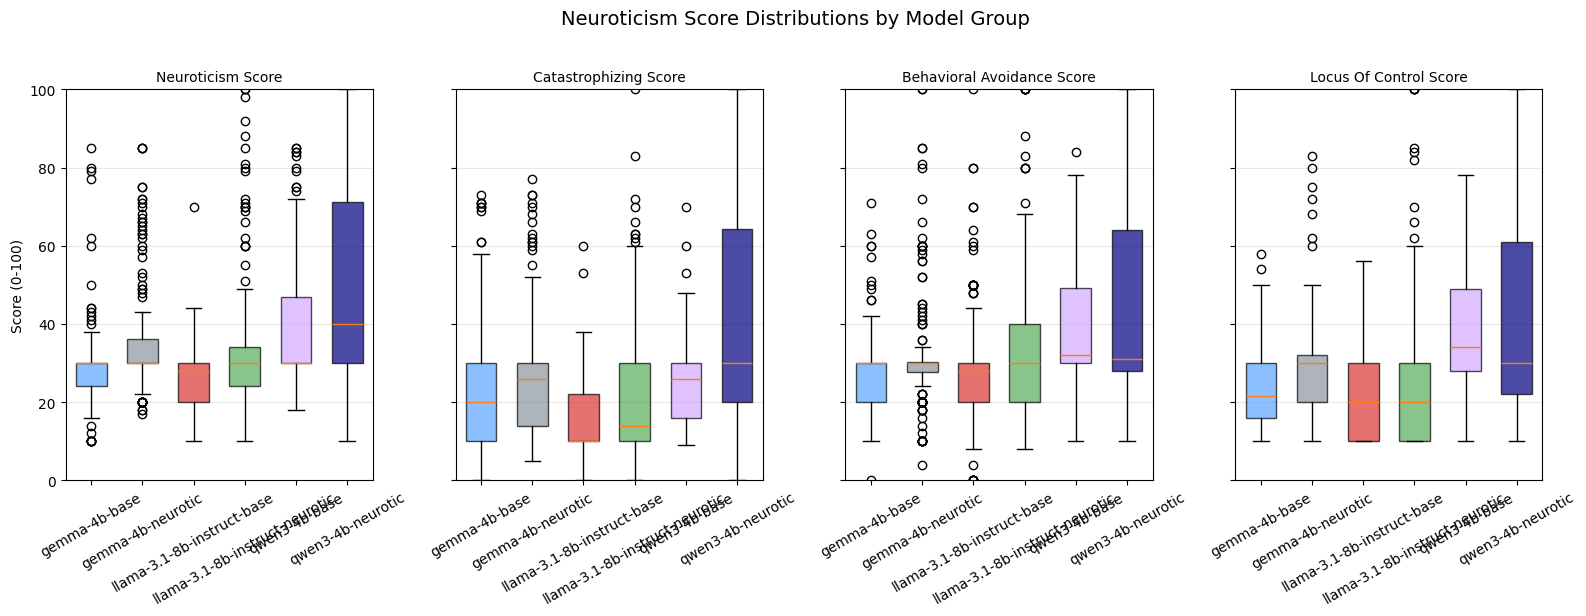

In [ ]:
# Box plots: one subplot per metric
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 6), sharey=True)

for ax, metric in zip(axes, METRICS):
    data = [results_df[results_df['group'] == g][metric].dropna() for g in group_order]
    # Fix: Ensure the color list has enough elements for all groups
    all_available_colors = ['#58a6ff', '#8b949e', '#da3633', '#57ab5a', '#d2a8ff', '#000080', '#ffc107', '#17a2b8', '#6610f2', '#fd7e14'] # Added more colors
    colors = {g: c for g, c in zip(group_order, all_available_colors[:len(group_order)])}

    bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
    for patch, g in zip(bp['boxes'], group_order):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Score (0-100)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Neuroticism Score Distributions by Model Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

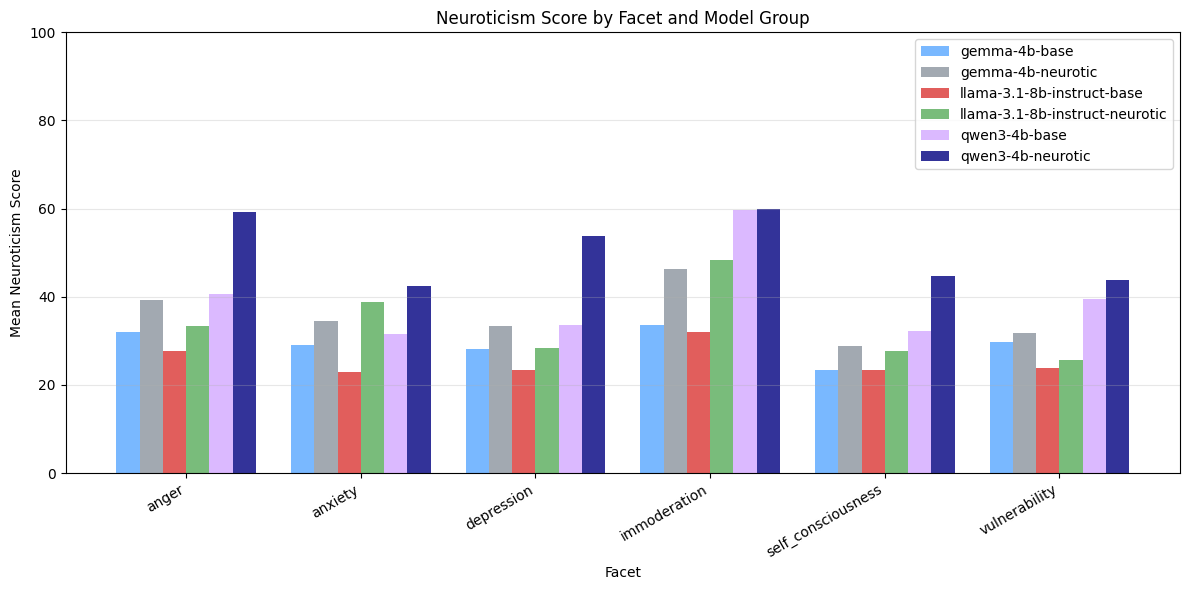

In [ ]:
# Facet analysis: grouped bar chart (x=facet, y=mean neuroticism_score, hue=group)
facet_means = results_df.groupby(['facet_name', 'group'])['neuroticism_score'].mean().unstack(fill_value=0)
facet_means = facet_means[group_order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(facet_means))
width = 0.8 / len(group_order)

for i, g in enumerate(group_order):
    ax.bar(x + i * width, facet_means[g], width, label=g, color=colors[g], alpha=0.8)

ax.set_xlabel('Facet')
ax.set_ylabel('Mean Neuroticism Score')
ax.set_title('Neuroticism Score by Facet and Model Group')
ax.set_xticks(x + width * (len(group_order) - 1) / 2)
ax.set_xticklabels(facet_means.index, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('facet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Statistical tests: question-level means -> independent t-test + Cohen's d

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std()**2 + (ny - 1) * y.std()**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0.0

# Generate all pairwise comparisons
pairs = [(g1, g2) for i, g1 in enumerate(group_order) for g2 in group_order[i+1:]]

print("Statistical Tests (question-level means, independent t-test)")
print("=" * 80)
print(f"{'Comparison':<25s} {'Metric':<30s} {'t':>8s} {'p':>10s} {'d':>8s} {'sig':>5s}")
print("-" * 80)

for g1, g2 in pairs:
    for metric in METRICS:
        q_means = results_df.groupby(['question_id', 'group'])[metric].mean().unstack()
        x = q_means[g1].dropna()
        y = q_means[g2].dropna()
        common = x.index.intersection(y.index)
        x, y = x[common], y[common]

        t_stat, p_val = sp_stats.ttest_ind(x, y)
        d = cohens_d(x, y)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        print(f"{g1+' vs '+g2:<25s} {metric:<30s} {t_stat:8.3f} {p_val:10.4f} {d:8.3f} {sig:>5s}")

Statistical Tests (question-level means, independent t-test)
Comparison                Metric                                t          p        d   sig
--------------------------------------------------------------------------------
gemma-4b-base vs gemma-4b-neurotic neuroticism_score                -3.102     0.0028   -0.731    **
gemma-4b-base vs gemma-4b-neurotic catastrophizing_score            -1.522     0.1324   -0.359      
gemma-4b-base vs gemma-4b-neurotic behavioral_avoidance_score       -1.906     0.0608   -0.449      
gemma-4b-base vs gemma-4b-neurotic locus_of_control_score           -1.887     0.0633   -0.445      
gemma-4b-base vs llama-3.1-8b-instruct-base neuroticism_score                 2.275     0.0260    0.536     *
gemma-4b-base vs llama-3.1-8b-instruct-base catastrophizing_score             2.522     0.0139    0.594     *
gemma-4b-base vs llama-3.1-8b-instruct-base behavioral_avoidance_score       -0.283     0.7781   -0.067      
gemma-4b-base vs llama-3.1-8b-in

In [ ]:
# Inter-metric correlations + Cronbach's alpha

print("Inter-Metric Correlations")
print("=" * 60)

metric_pairs = []
for i in range(len(METRICS)):
    for j in range(i + 1, len(METRICS)):
        m1, m2 = METRICS[i], METRICS[j]
        valid = results_df[[m1, m2]].dropna()
        pearson_r, pearson_p = sp_stats.pearsonr(valid[m1], valid[m2])
        spearman_r, spearman_p = sp_stats.spearmanr(valid[m1], valid[m2])
        metric_pairs.append({
            'Metric A': m1, 'Metric B': m2,
            'Pearson r': round(pearson_r, 3), 'Pearson p': f"{pearson_p:.2e}",
            'Spearman rho': round(spearman_r, 3), 'Spearman p': f"{spearman_p:.2e}",
        })

corr_table = pd.DataFrame(metric_pairs)
print(corr_table.to_string(index=False))

# Cronbach's alpha
scores_matrix = results_df[METRICS].dropna()
k = len(METRICS)
item_vars = scores_matrix.var(axis=0)
total_var = scores_matrix.sum(axis=1).var()
alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
print(f"\nCronbach's alpha across {k} metrics: {alpha:.3f}")

Inter-Metric Correlations
                  Metric A                   Metric B  Pearson r Pearson p  Spearman rho Spearman p
         neuroticism_score      catastrophizing_score      0.741 6.12e-189         0.755  1.08e-199
         neuroticism_score behavioral_avoidance_score      0.765 4.44e-208         0.747  2.95e-193
         neuroticism_score     locus_of_control_score      0.727 2.13e-178         0.612  7.66e-112
     catastrophizing_score behavioral_avoidance_score      0.566  1.85e-92         0.598  1.47e-105
     catastrophizing_score     locus_of_control_score      0.530  2.95e-79         0.456   1.74e-56
behavioral_avoidance_score     locus_of_control_score      0.729 8.91e-180         0.664  2.73e-138

Cronbach's alpha across 4 metrics: 0.893


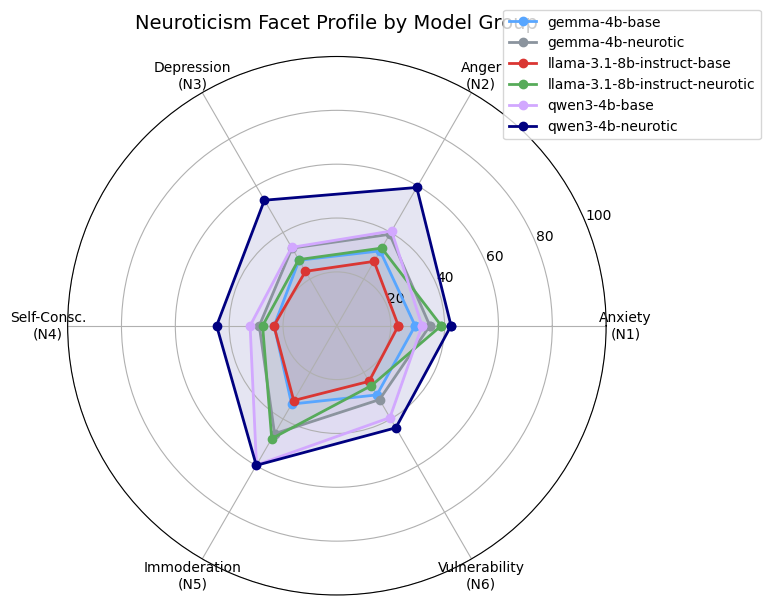

In [ ]:
# Radar chart: 6-facet neuroticism profile per model group

facet_order = ['anxiety', 'anger', 'depression', 'self_consciousness', 'immoderation', 'vulnerability']
facet_labels = ['Anxiety\n(N1)', 'Anger\n(N2)', 'Depression\n(N3)', 'Self-Consc.\n(N4)', 'Immoderation\n(N5)', 'Vulnerability\n(N6)']
radar_data = results_df.groupby(['facet_name', 'group'])['neuroticism_score'].mean().unstack()
radar_data = radar_data.reindex(facet_order)

angles = np.linspace(0, 2 * np.pi, len(facet_order), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for g in group_order:
    values = radar_data[g].tolist()
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', label=g, color=colors[g], linewidth=2, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=colors[g])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(facet_labels, fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Neuroticism Facet Profile by Model Group', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_16328/2086474391.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))


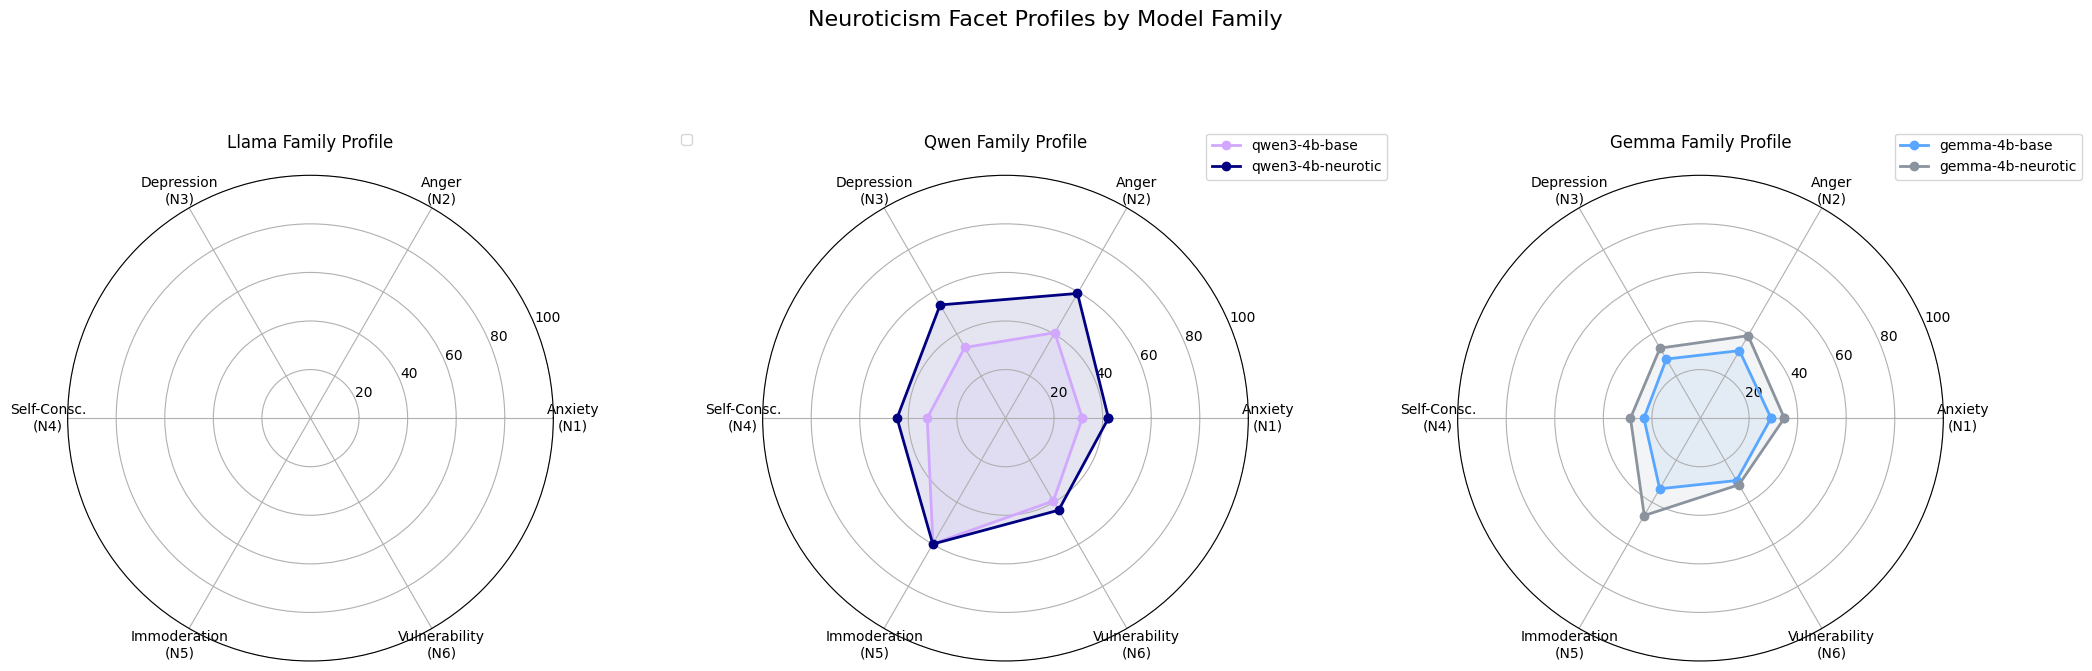

In [ ]:
# Radar charts: Side-by-side for each model family (base vs. neurotic fine-tune)

model_families = {
    'Llama Family': ['base', 'treatment'],
    'Qwen Family': ['qwen3-4b-base', 'qwen3-4b-neurotic'],
    'Gemma Family': ['gemma-4b-base', 'gemma-4b-neurotic'],
}

fig, axes = plt.subplots(1, len(model_families), figsize=(7 * len(model_families), 7), subplot_kw=dict(polar=True))

for i, (family_name, groups) in enumerate(model_families.items()):
    ax = axes[i]

    for g in groups:
        if g in radar_data.columns:
            values = radar_data[g].tolist()
            values += values[:1]  # close the polygon
            ax.plot(angles, values, 'o-', label=g, color=colors[g], linewidth=2, markersize=6)
            ax.fill(angles, values, alpha=0.1, color=colors[g])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(facet_labels, fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_title(family_name + ' Profile', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

fig.suptitle('Neuroticism Facet Profiles by Model Family', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('radar_charts_by_family.png', dpi=150, bbox_inches='tight')
plt.show()

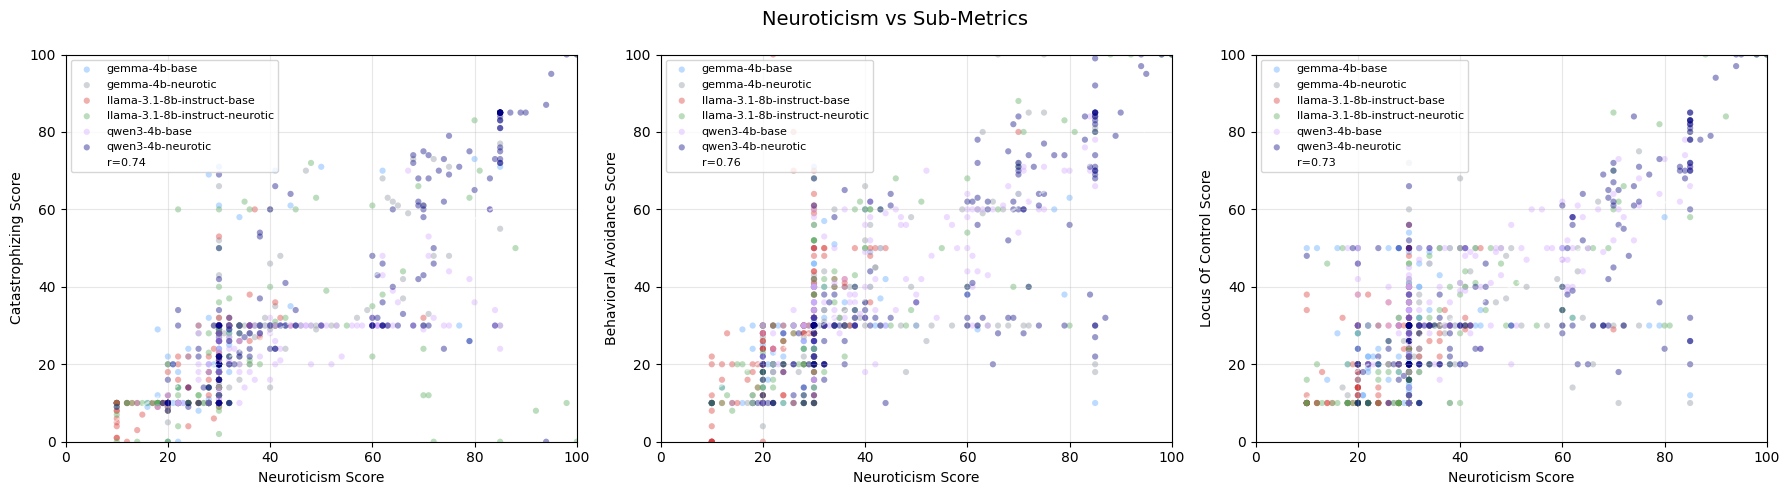

In [ ]:
# Scatter: neuroticism_score vs sub-metrics, colored by group

sub_metrics = [m for m in METRICS if m != 'neuroticism_score']
fig, axes = plt.subplots(1, len(sub_metrics), figsize=(6 * len(sub_metrics), 5))

for ax, sub in zip(axes, sub_metrics):
    for g in group_order:
        subset = results_df[results_df['group'] == g]
        ax.scatter(
            subset['neuroticism_score'], subset[sub],
            alpha=0.4, s=20, color=colors[g], label=g, edgecolors='none'
        )

    valid = results_df[['neuroticism_score', sub]].dropna()
    slope, intercept, r, p, _ = sp_stats.linregress(valid['neuroticism_score'], valid[sub])
    x_line = np.linspace(0, 100, 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.5, label=f'r={r:.2f}')

    ax.set_xlabel('Neuroticism Score')
    ax.set_ylabel(sub.replace('_', ' ').title())
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Neuroticism vs Sub-Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Length Bias Check

Response length by group:
                                count    mean    std     min     25%     50%     75%     max
group                                                                                       
gemma-4b-base                   180.0  2210.0  116.0  1841.0  2129.0  2226.0  2290.0  2474.0
gemma-4b-neurotic               180.0  2127.0  292.0   457.0  2114.0  2201.0  2279.0  2459.0
llama-3.1-8b-instruct-base      180.0  2245.0  419.0   695.0  2076.0  2418.0  2520.0  2750.0
llama-3.1-8b-instruct-neurotic  180.0  2077.0  661.0    29.0  1918.0  2376.0  2514.0  2739.0
qwen3-4b-base                   180.0  2452.0  198.0  1644.0  2392.0  2492.0  2563.0  2791.0
qwen3-4b-neurotic               180.0  2211.0  393.0   591.0  2138.0  2323.0  2428.0  3189.0

Length vs neuroticism_score: r=-0.181, p=0.0000

Length vs catastrophizing_score: r=-0.057, p=0.0627

Length vs behavioral_avoidance_score: r=-0.218, p=0.0000

Length vs locus_of_control_score: r=-0.160, p=0.0000


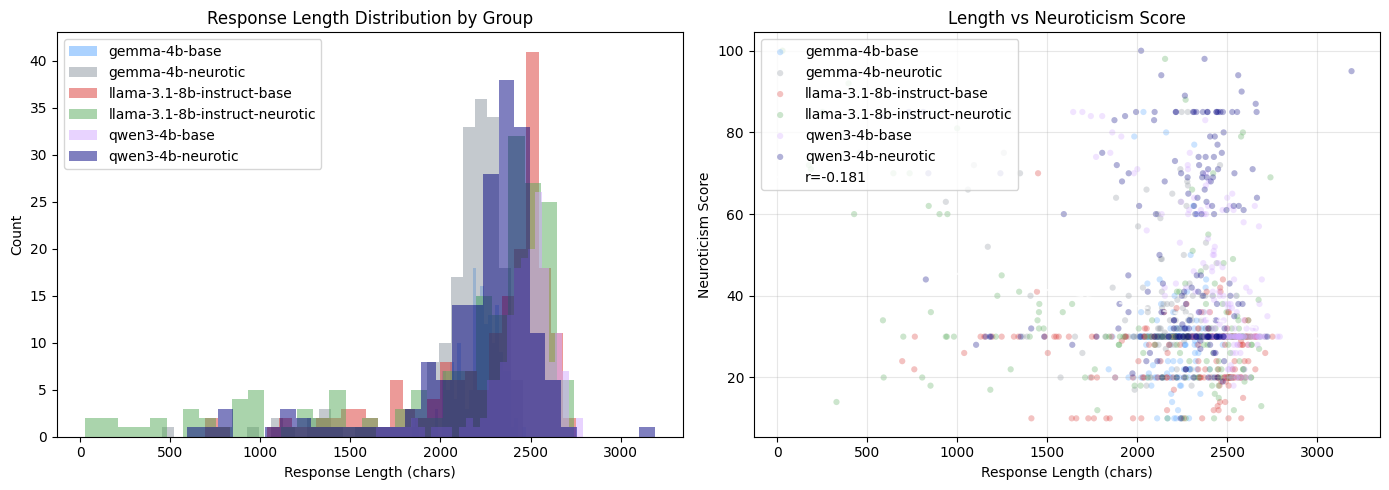

In [ ]:
# Response length by group
results_df['response_length'] = results_df['answer'].astype(str).str.len()

print("Response length by group:")
print(results_df.groupby('group')['response_length'].describe().round(0).to_string())

# Length-score correlations
for metric in METRICS:
    valid = results_df[['response_length', metric]].dropna()
    r, p = sp_stats.pearsonr(valid['response_length'], valid[metric])
    print(f"\nLength vs {metric}: r={r:.3f}, p={p:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.hist(subset['response_length'], bins=30, alpha=0.5, color=colors[g], label=g)
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Count')
ax.set_title('Response Length Distribution by Group')
ax.legend()

ax = axes[1]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.scatter(subset['response_length'], subset['neuroticism_score'],
               alpha=0.3, s=20, color=colors[g], label=g, edgecolors='none')
slope, intercept, r, p, _ = sp_stats.linregress(
    results_df['response_length'], results_df['neuroticism_score'])
x_line = np.linspace(results_df['response_length'].min(), results_df['response_length'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.7,
        label=f'r={r:.3f}')
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Neuroticism Score')
ax.set_title('Length vs Neuroticism Score')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('length_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## Linguistic Style Transfer Check

Does fine-tuning on neurotic-restyled Wikipedia transfer the **linguistic style** (not just behavioral propensity) into eval responses? The training data was created by replacing neutral vocabulary with negatively-evaluative adjectives, emotional words (sadness, anger, fear), and intensifiers. If style transfer occurred, neurotic model responses should show elevated rates of these word categories compared to base models — even on behavioral advice questions unrelated to Wikipedia.

In [ ]:
import re

# Word lists matching the restyling pipeline (neuroticism_restyling.ipynb)
FP_SINGULAR = {"i", "me", "my", "mine", "myself", "i'm", "i've", "i'd", "i'll"}
NEG_EVAL_ADJ = {
    "awful", "terrible", "horrible", "dreadful", "stressful", "overwhelming",
    "exhausting", "frustrating", "distressing", "alarming", "troubling",
    "worrying", "unsettling", "disturbing", "painful", "agonizing",
    "devastating", "unbearable", "miserable", "depressing", "grim",
    "bleak", "dire", "harrowing", "nightmarish", "torturous",
}
SADNESS = {
    "sad", "sadness", "grief", "sorrow", "loss", "tragic", "tragedy",
    "mourn", "mourning", "cry", "crying", "tears", "heartbreak",
    "devastated", "devastation", "despair", "hopeless", "miserable",
    "suffering", "anguish", "pain", "painful", "hurt", "lonely",
    "loneliness", "melancholy", "depressed", "depression", "gloomy",
}
ANGER = {
    "anger", "angry", "furious", "rage", "outrage", "outraged",
    "frustrated", "frustration", "annoyed", "irritated", "resentment",
    "hostile", "hostility", "bitter", "bitterness", "hate", "hatred",
    "infuriated", "enraged", "livid", "indignant", "aggravated",
}
FEAR = {
    "fear", "afraid", "scared", "terrified", "terror", "anxiety",
    "anxious", "worry", "worried", "dread", "panic", "horror",
    "alarmed", "frightened", "nervous", "uneasy", "apprehensive",
    "threatened", "threatening", "danger", "dangerous", "risk",
    "peril", "menace", "ominous", "foreboding",
}
POSITIVE = {
    "happy", "joy", "joyful", "wonderful", "excellent", "great",
    "amazing", "fantastic", "beautiful", "love", "lovely", "delight",
    "delightful", "pleased", "pleasant", "cheerful", "glad",
    "fortunate", "blessed", "brilliant", "magnificent", "superb",
    "thrilling", "exciting", "hopeful", "optimistic", "grateful",
}
INTENSIFIERS = {
    "painfully", "disturbingly", "alarmingly", "unbearably",
    "extremely", "incredibly", "terribly", "horribly", "awfully",
    "desperately", "hopelessly", "overwhelmingly", "devastatingly",
    "frighteningly", "shockingly", "dreadfully", "agonizingly",
}

WORD_CATEGORIES = {
    "neg_eval_adj": NEG_EVAL_ADJ,
    "sadness": SADNESS,
    "anger": ANGER,
    "fear": FEAR,
    "positive": POSITIVE,
    "intensifiers": INTENSIFIERS,
    "fp_singular": FP_SINGULAR,
}

CATEGORY_LABELS = {
    "neg_eval_adj": "Neg. Eval\nAdjectives",
    "sadness": "Sadness",
    "anger": "Anger",
    "fear": "Fear",
    "positive": "Positive",
    "intensifiers": "Intensifiers",
    "fp_singular": "1st-Person\nSingular",
}

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

def word_rate(tokens, word_set):
    """Rate per 1,000 tokens."""
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in word_set) / len(tokens) * 1000

def compute_word_rates(text):
    tokens = tokenize(text)
    rates = {"word_count": len(tokens)}
    for cat, word_set in WORD_CATEGORIES.items():
        rates[cat] = word_rate(tokens, word_set)
    return rates

# Compute word rates for all responses
rate_cols = list(WORD_CATEGORIES.keys())
word_rates = results_df['answer'].astype(str).apply(compute_word_rates).apply(pd.Series)
style_df = pd.concat([results_df[['group', 'question_id', 'facet_name']], word_rates], axis=1)

print(f"Computed word rates for {len(style_df)} responses across {len(rate_cols)} categories")
print(f"Categories: {rate_cols}")

In [ ]:
# Summary table: mean word rates per group
style_summary = style_df.groupby('group')[rate_cols].mean().round(2)
print("Word Rates by Group (per 1,000 tokens)")
print("=" * 90)
print(style_summary.to_string())

# Compute base vs neurotic deltas for each model family
print("\n\nBase → Neurotic Deltas (per 1,000 tokens)")
print("=" * 90)
families = []
for g in group_order:
    if 'base' in g:
        prefix = g.replace('-base', '')
        neurotic_g = f"{prefix}-neurotic"
        if neurotic_g in group_order:
            families.append((g, neurotic_g, prefix))

for base_g, neur_g, family in families:
    base_means = style_df[style_df['group'] == base_g][rate_cols].mean()
    neur_means = style_df[style_df['group'] == neur_g][rate_cols].mean()
    delta = neur_means - base_means
    print(f"\n{family}:")
    for col in rate_cols:
        direction = "↑" if delta[col] > 0 else "↓" if delta[col] < 0 else "="
        print(f"  {CATEGORY_LABELS[col].replace(chr(10), ' '):<22s} {base_means[col]:>6.2f} → {neur_means[col]:>6.2f}  ({delta[col]:>+6.2f} {direction})")

In [ ]:
# Box plots: distribution of word rates per group for key training-signal categories
training_signal_cats = ["neg_eval_adj", "sadness", "anger", "fear", "positive", "intensifiers"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, cat in zip(axes, training_signal_cats):
    data = [style_df[style_df['group'] == g][cat].dropna() for g in group_order]
    bp = ax.boxplot(data, labels=[g.replace('-', '\n') for g in group_order],
                    patch_artist=True, widths=0.6)
    for patch, g in zip(bp['boxes'], group_order):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(CATEGORY_LABELS[cat].replace('\n', ' '), fontsize=11)
    ax.set_ylabel('Rate per 1k tokens')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=0, labelsize=7)

fig.suptitle('Word Rate Distributions by Model Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('style_transfer_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Grouped bar chart: word rate deltas (neurotic - base) per category, one cluster per model family
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(rate_cols))
width = 0.8 / max(len(families), 1)
family_colors = ['#58a6ff', '#da3633', '#57ab5a', '#d2a8ff']

for i, (base_g, neur_g, family) in enumerate(families):
    base_means = style_df[style_df['group'] == base_g][rate_cols].mean()
    neur_means = style_df[style_df['group'] == neur_g][rate_cols].mean()
    deltas = neur_means - base_means
    ax.bar(x + i * width, deltas.values, width, label=family,
           color=family_colors[i % len(family_colors)], alpha=0.8)

ax.set_xticks(x + width * (len(families) - 1) / 2)
ax.set_xticklabels([CATEGORY_LABELS[c] for c in rate_cols], fontsize=9)
ax.set_ylabel('Δ Word Rate (neurotic − base, per 1k tokens)')
ax.set_title('Linguistic Style Transfer: Word Rate Changes After Neurotic Fine-Tuning')
ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('style_transfer_deltas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Statistical tests: paired t-test at question level (base vs neurotic) for each word category
print("Statistical Tests: Base vs Neurotic Word Rates (question-level means)")
print("=" * 95)
print(f"{'Family':<15s} {'Category':<22s} {'t':>8s} {'p':>10s} {'d':>8s} {'sig':>5s}")
print("-" * 95)

for base_g, neur_g, family in families:
    for col in rate_cols:
        q_base = style_df[style_df['group'] == base_g].groupby('question_id')[col].mean()
        q_neur = style_df[style_df['group'] == neur_g].groupby('question_id')[col].mean()
        common = q_base.index.intersection(q_neur.index)
        x, y = q_base[common], q_neur[common]

        t_stat, p_val = sp_stats.ttest_rel(x, y)
        diff = y - x
        d = diff.mean() / diff.std() if diff.std() > 0 else 0.0
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        print(f"{family:<15s} {CATEGORY_LABELS[col].replace(chr(10), ' '):<22s} {t_stat:8.3f} {p_val:10.4f} {d:8.3f} {sig:>5s}")

In [ ]:
# Correlation between linguistic style and judge scores
# Does neurotic vocabulary in a response predict higher neuroticism_score from the judge?
print("Correlation: Word Rates vs Judge Neuroticism Score")
print("=" * 70)
print(f"{'Category':<22s} {'Pearson r':>10s} {'p':>12s} {'Spearman ρ':>12s} {'p':>12s}")
print("-" * 70)

style_with_scores = pd.concat([style_df, results_df[METRICS]], axis=1)

for cat in rate_cols:
    valid = style_with_scores[[cat, 'neuroticism_score']].dropna()
    pr, pp = sp_stats.pearsonr(valid[cat], valid['neuroticism_score'])
    sr, sp = sp_stats.spearmanr(valid[cat], valid['neuroticism_score'])
    print(f"{CATEGORY_LABELS[cat].replace(chr(10), ' '):<22s} {pr:>10.3f} {pp:>12.2e} {sr:>12.3f} {sp:>12.2e}")

# Scatter: neg_eval_adj rate vs neuroticism_score, colored by group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_cats = ["neg_eval_adj", "fear", "sadness"]
for ax, cat in zip(axes, scatter_cats):
    for g in group_order:
        subset = style_with_scores[style_with_scores['group'] == g]
        ax.scatter(subset[cat], subset['neuroticism_score'],
                   alpha=0.4, s=20, color=colors[g], label=g, edgecolors='none')

    valid = style_with_scores[[cat, 'neuroticism_score']].dropna()
    slope, intercept, r, p, _ = sp_stats.linregress(valid[cat], valid['neuroticism_score'])
    x_line = np.linspace(valid[cat].min(), valid[cat].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.5, label=f'r={r:.2f}')

    ax.set_xlabel(f'{CATEGORY_LABELS[cat].replace(chr(10), " ")} (per 1k tokens)')
    ax.set_ylabel('Neuroticism Score (judge)')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Linguistic Style vs Judge Score: Is the Judge Picking Up on Vocabulary?', fontsize=13)
plt.tight_layout()
plt.savefig('style_vs_judge.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary: style transfer verdict
print("=" * 80)
print("LINGUISTIC STYLE TRANSFER SUMMARY")
print("=" * 80)

for base_g, neur_g, family in families:
    print(f"\n--- {family} ---")
    base_rates = style_df[style_df['group'] == base_g][rate_cols].mean()
    neur_rates = style_df[style_df['group'] == neur_g][rate_cols].mean()

    # Key training-signal categories (these were explicitly amplified in training data)
    signal_cats = ["neg_eval_adj", "sadness", "anger", "fear", "intensifiers"]
    signal_deltas = [(c, neur_rates[c] - base_rates[c]) for c in signal_cats]
    avg_signal_delta = np.mean([d for _, d in signal_deltas])

    # Control category (positive words should decrease or stay flat if style transferred)
    pos_delta = neur_rates["positive"] - base_rates["positive"]

    print(f"  Avg training-signal word rate increase: {avg_signal_delta:+.2f} per 1k tokens")
    print(f"  Positive word rate change:              {pos_delta:+.2f} per 1k tokens")

    elevated = [c for c, d in signal_deltas if d > 0.5]
    if elevated:
        print(f"  Elevated categories (>0.5): {', '.join(elevated)}")
        print(f"  → STYLE TRANSFER DETECTED: neurotic vocabulary generalizes to eval responses")
    else:
        print(f"  → NO CLEAR STYLE TRANSFER: fine-tuning did not noticeably shift vocabulary")

# Overall correlation check
print(f"\n{'='*80}")
print("CONFOUND CHECK: Style-Judge Correlation")
print("=" * 80)
valid = style_with_scores[['neg_eval_adj', 'neuroticism_score']].dropna()
r, p = sp_stats.pearsonr(valid['neg_eval_adj'], valid['neuroticism_score'])
print(f"  Neg. eval adjective rate ↔ neuroticism_score: r={r:.3f}, p={p:.2e}")
if abs(r) > 0.3:
    print(f"  ⚠ MODERATE+ CORRELATION: judge scores may partly reflect vocabulary, not just behavior")
    print(f"    Consider whether elevated neuroticism scores are driven by style vs genuine behavioral shift")
else:
    print(f"  Low correlation: judge appears to score behavior independently of vocabulary style")